In [1]:
import numpy as np
import librosa
from scipy.signal import find_peaks
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import pi
from scipy import signal
import soundfile as sf
import noisereduce as nr
import math
from scipy.signal import find_peaks, medfilt
import parselmouth
import soundfile as sf

c:\Users\jiyon\Desktop\Programming_projects\UNSW\musictransformationanalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

song_sections = {
    "Kanye West": [
        (0, 52, "Verse 1"),
        (53, 75, "Chorus"),
        (76, 90, "Verse 2"),
        (91, 160, "Chorus")
    ],
    "Cardi B": [
        (0,  14, "Intro"),
        (15, 29, "Chorus"),
        (30, 57, "Verse 1"),
        (58, 71, "Verse 2"),
        (72, 85, "Chorus"),
        (86, 115, "Verse 3"),
        (156, 136, "Verse 4"),
        (137, 165, "Chorus"),
        (166, 187, "Outro"),
    ],
    "Elton John": [
        (0, 33, "Verse 1"),
        (34, 66, "Chorus"),
        (75, 102, "Verse 2"),
        (103, 135, "Chorus"),
        (136, 171, "Solo"),
        (172, 222, "Chorus")
    ],
    "Tom Macdonald": [
        (5, 50, "Verse 1"),
        (51, 61, "Chorus"),
        (62, 73, "Post-Chorus"),
        (73, 107, "Verse 2"),
        (108, 118, "Chorus"),
        (119, 129, "Post-Chorus"),
        (130, 176, "Verse 3"),
        (177, 220, "Verse 4"),
        (221, 231, "Bridge"),
        (232, 271, "Chorus"),
        (242, 253, "Post-Chorus"),
        (254, 264, "Chorus")
        
    ],
    "Kanye West (AI)": [
        (23, 58, "Verse 1"),
        (59, 86, "Chorus"),
        (87, 97, "Verse 2"),
        (98, 126, "Chorus")
    ],
    "Cardi B (AI)": [
        (0,  15, "Intro"),
        (16, 29, "Chorus"),
        (30, 58, "Verse 1"),
        (59, 75, "Verse 2"),
        (76, 89, "Chorus"),
        (90, 118, "Verse 3"),
        (119, 140, "Verse 4"),
        (141, 173, "Chorus"),
        (174, 205, "Outro"),
    ],
    "Elton John (AI)": [
        (7, 33, "Verse 1"),
        (34, 69, "Chorus"),
        (70, 97, "Verse 2"),
        (98, 133, "Chorus"),
        (134, 161, "Solo"),
        (161, 221, "Chorus")
    ],
    "Tom Macdonald (AI)": [
        (11, 55, "Verse 1"),
        (56, 67, "Chorus"),
        (68, 77, "Post-Chorus"),
        (78, 112, "Verse 2"),
        (113, 123, "Chorus"),
        (124, 135, "Post-Chorus"),
        (136, 174, "Verse 3"),
        (175, 211, "Verse 4"),
        (212, 222, "Bridge"),
        (220, 230, "Chorus"),
        (231, 241, "Post-Chorus"),
        (242, 256, "Chorus")
        
    ]
}




In [3]:
vocal_paths = {
    "Kanye West": "../song1/vocals.wav",           
    "Cardi B": "../song2/vocals.wav",              
    "Elton John": "../song3/vocals.wav",           
    "Tom Macdonald": "../song4/vocals.wav",        
    "Kanye West (AI)": "../song1/vocals_ai.wav",   
    "Cardi B (AI)": "../song2/vocals_ai.wav",      
    "Elton John (AI)": "../song3/vocals_ai.wav",   
    "Tom Macdonald (AI)": "../song4/vocals_ai.wav" 
}

def preprocess_music_signals(paths, max_duration=360):
    """
    Simplified music preprocessing with essential steps:
    - Pre-emphasis
    - Framing & windowing
    - Silence removal
    - Frequency domain conversion
    - Parselmouth-optimized preprocessing
    """
    
    out = {}
    
    for name, path in paths.items():
        print(f"Processing {name}...")
        
        # 1. Load audio
        y, sr = librosa.load(path, sr=22050, mono=True, duration=max_duration)
        
        # 2. Pre-emphasis (H(z) = 1 - μz^(-1))
        y_preemphasized = np.append(y[0], y[1:] - 0.97 * y[:-1])
        
        # 3. Noise reduction
        noise_profile = y_preemphasized[:int(sr * 0.5)]
        y_denoised = nr.reduce_noise(y=y_preemphasized, y_noise=noise_profile, sr=sr)
        
        
        # 5. Enhanced preprocessing for Parselmouth analysis
        y = preprocess_demucs_vocals(y_denoised, sr)
        
        # 6. Convert to frequency domain (STFT)
        stft = librosa.stft(y, n_fft=2048, hop_length=512)
        magnitude = np.abs(stft)
        
        out[name] = {
            "y": y,                    # Single processed audio
            "stft": stft,
            "magnitude": magnitude,
            "sr": sr
        }
    
    return out

def preprocess_demucs_vocals(y, sr):
    """Enhanced preprocessing specifically for Demucs-extracted vocals"""
    b, a = signal.butter(6, 100/(sr/2), 'highpass') # remove low frequency artifacts
    y = signal.filtfilt(b, a, y)
    
    D = librosa.stft(y, n_fft=2048, hop_length=512) # convert to frequency domain
    magnitude = np.abs(D)
    
    frame_energy = np.mean(magnitude**2, axis=0)
    noise_threshold = np.percentile(frame_energy, 25) # find lowest 25% energy and assume it's artifacts
    noise_frames = frame_energy < noise_threshold
    
    if np.sum(noise_frames) > 3:
        noise_profile = np.median(magnitude[:, noise_frames], axis=1)
        magnitude_clean = magnitude - 0.8 * noise_profile[:, np.newaxis] # reduce by 80%
        magnitude_clean = np.maximum(magnitude_clean, magnitude * 0.2)  # preserve at least 20%
        
        # Reconstruct audio
        D_clean = magnitude_clean * np.exp(1j * np.angle(D))
        y = librosa.istft(D_clean, hop_length=512)
    
    b, a = signal.butter(4, 8000/(sr/2), 'lowpass')    # mild low-pass to reduce high-frequency artifacts

    y = signal.filtfilt(b, a, y)
    
    # 4. Remove DC offset and normalize
    y = y - np.mean(y)
    y = y / (np.max(np.abs(y)) + 1e-9)
    
    return y

# Apply to your vocals
vocals = preprocess_music_signals(vocal_paths, max_duration=360)

Processing Kanye West...
Processing Cardi B...
Processing Elton John...
Processing Tom Macdonald...
Processing Kanye West (AI)...
Processing Cardi B (AI)...
Processing Elton John (AI)...
Processing Tom Macdonald (AI)...


In [4]:

# # Save all processed vocals
# for name, data in vocals.items():
#     # Create safe filename
#     filename = f"processed_{name.replace(' ', '_').replace('(', '').replace(')', '')}.wav"
#     sf.write(filename, data['y'], data['sr'])
#     print(f"✅ Saved: {filename}")

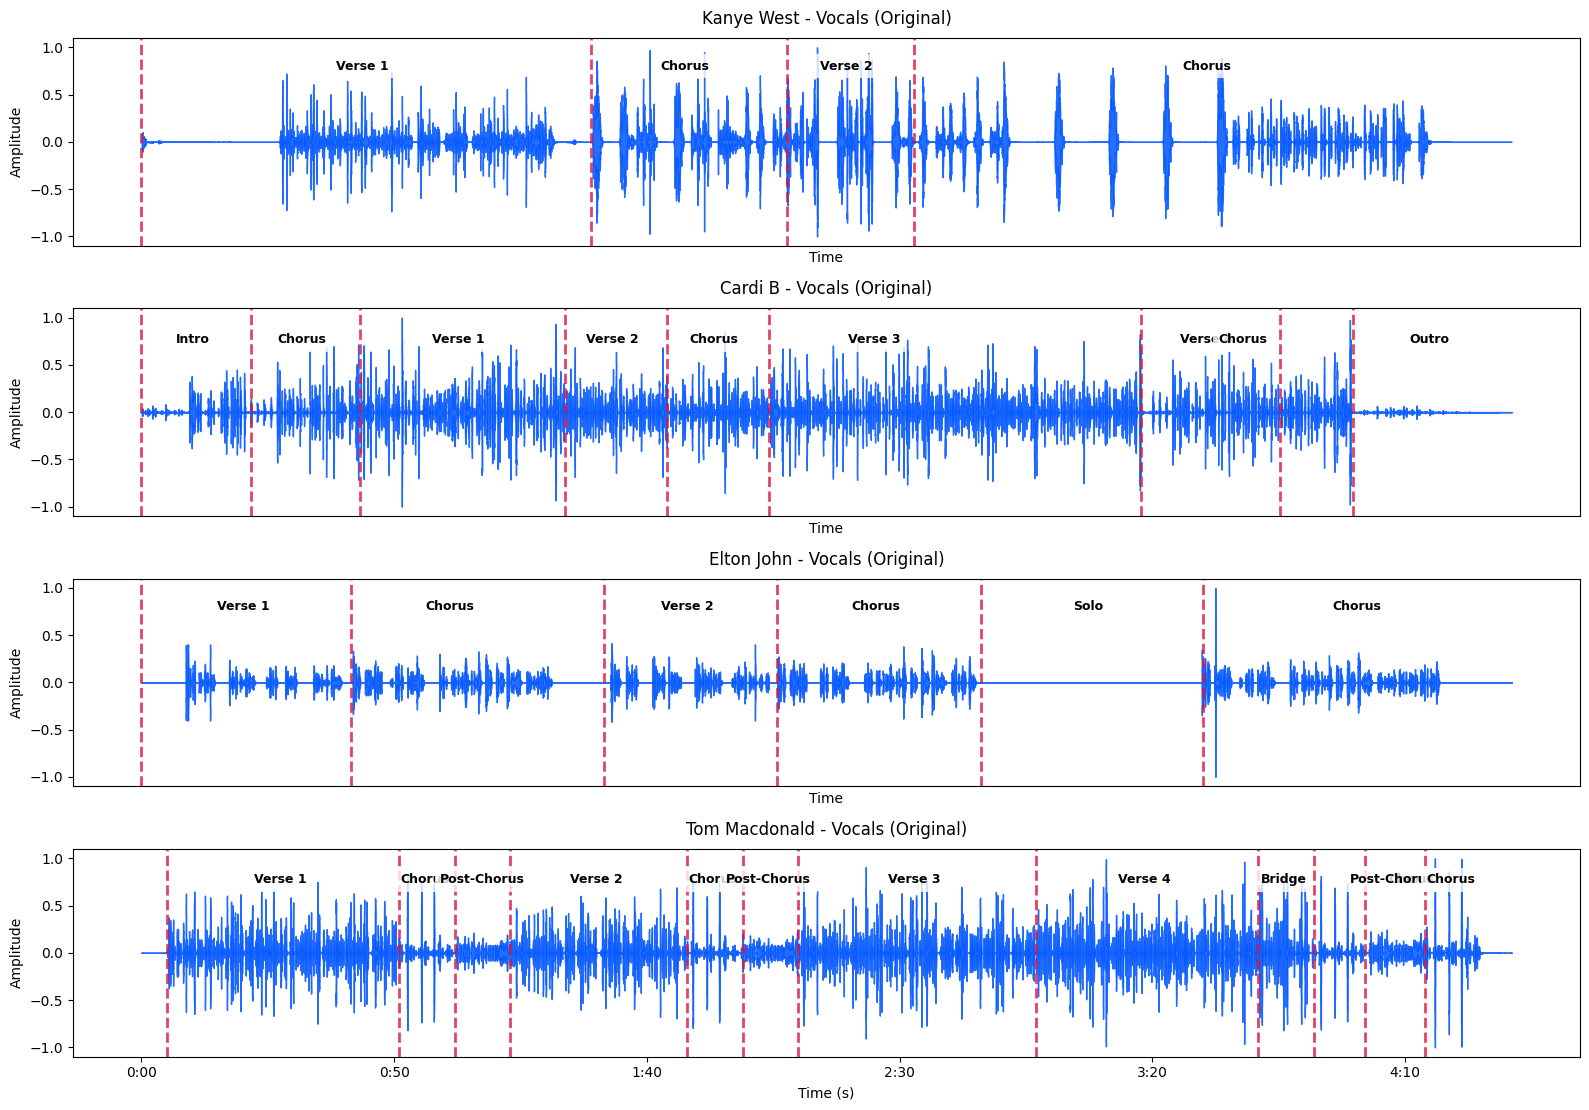

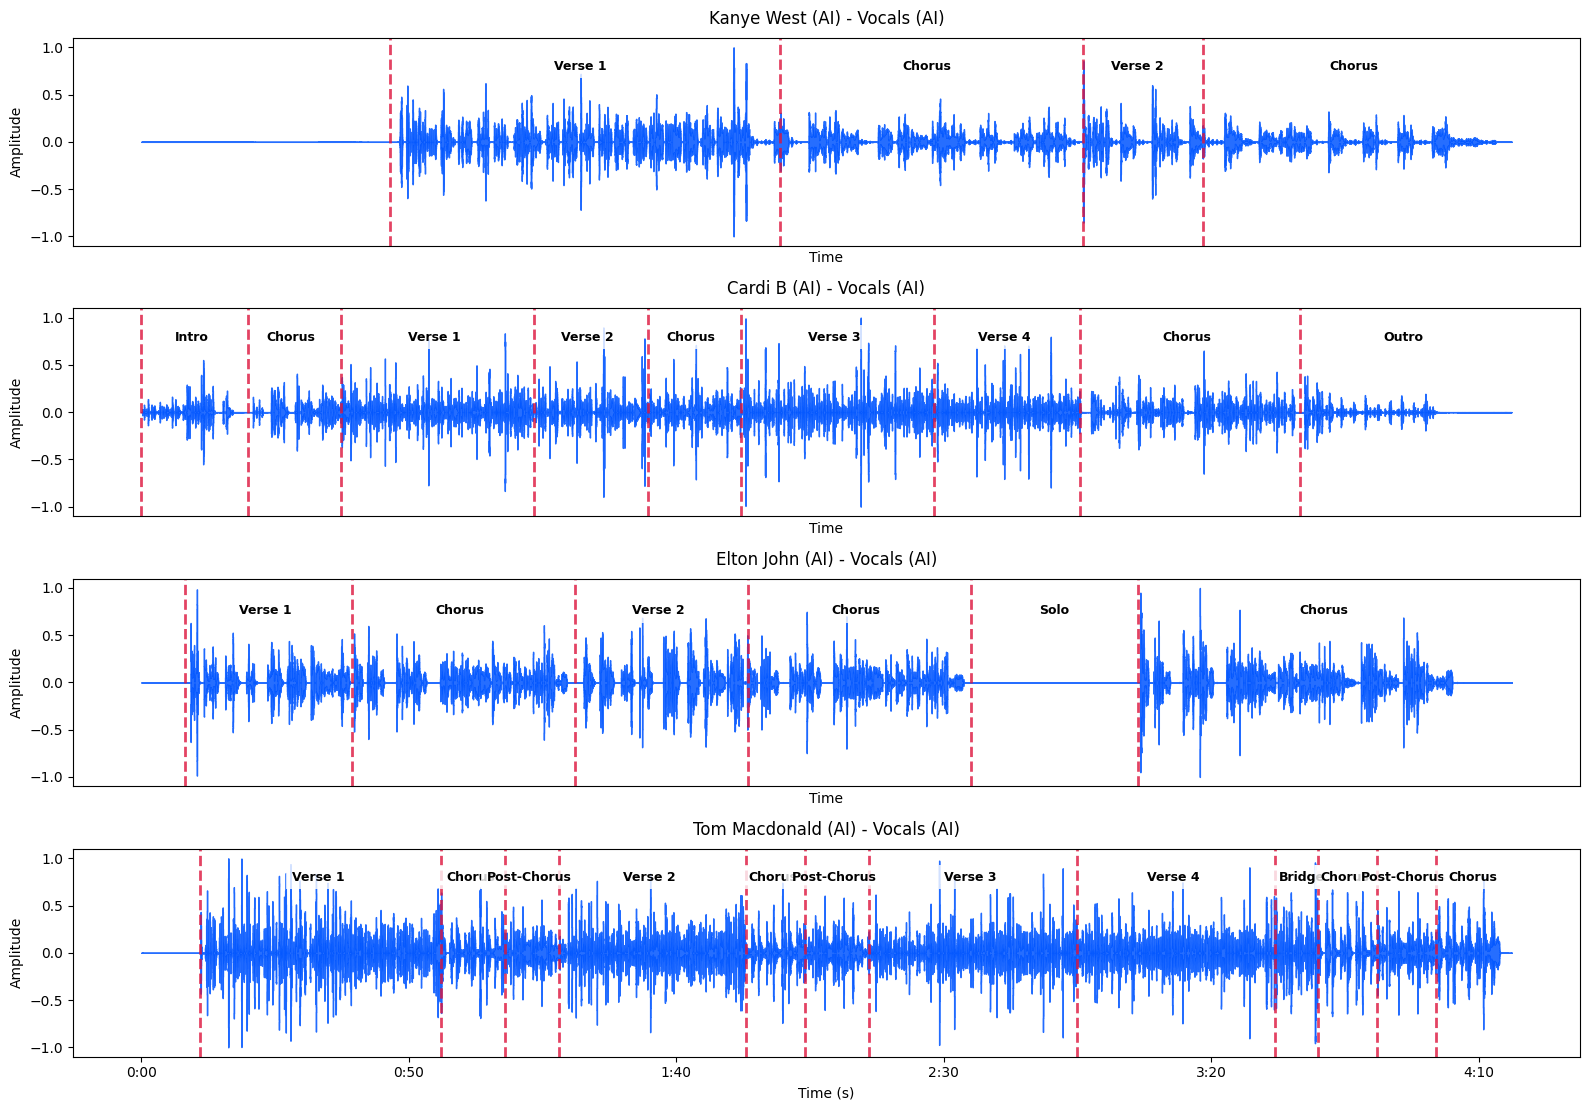

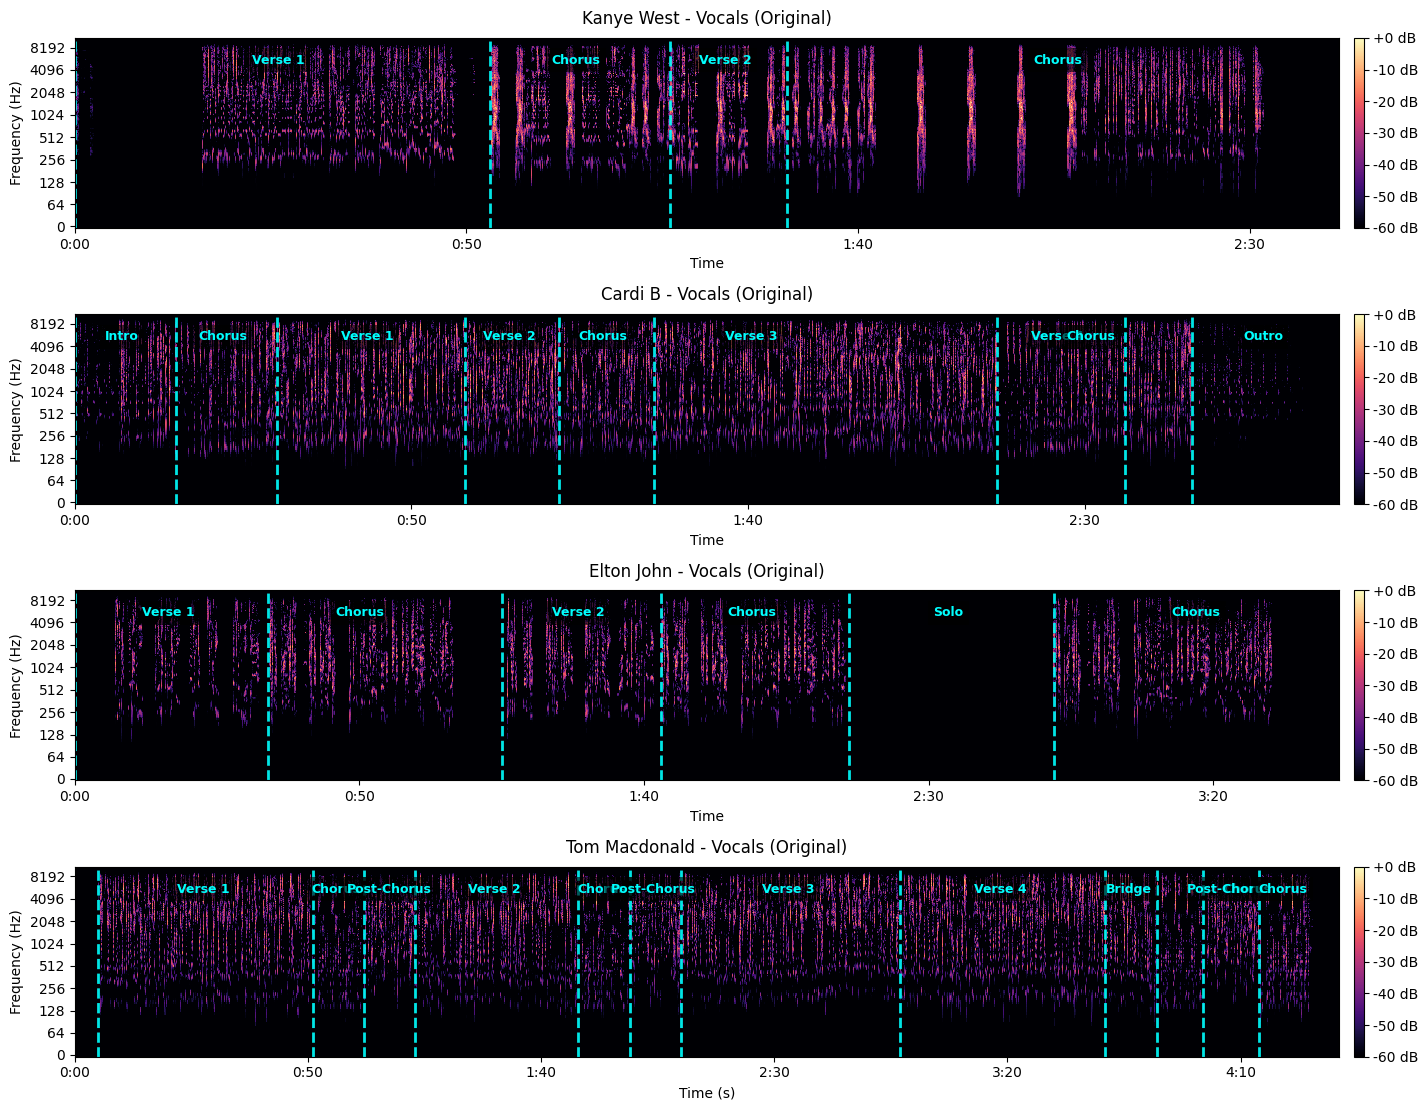

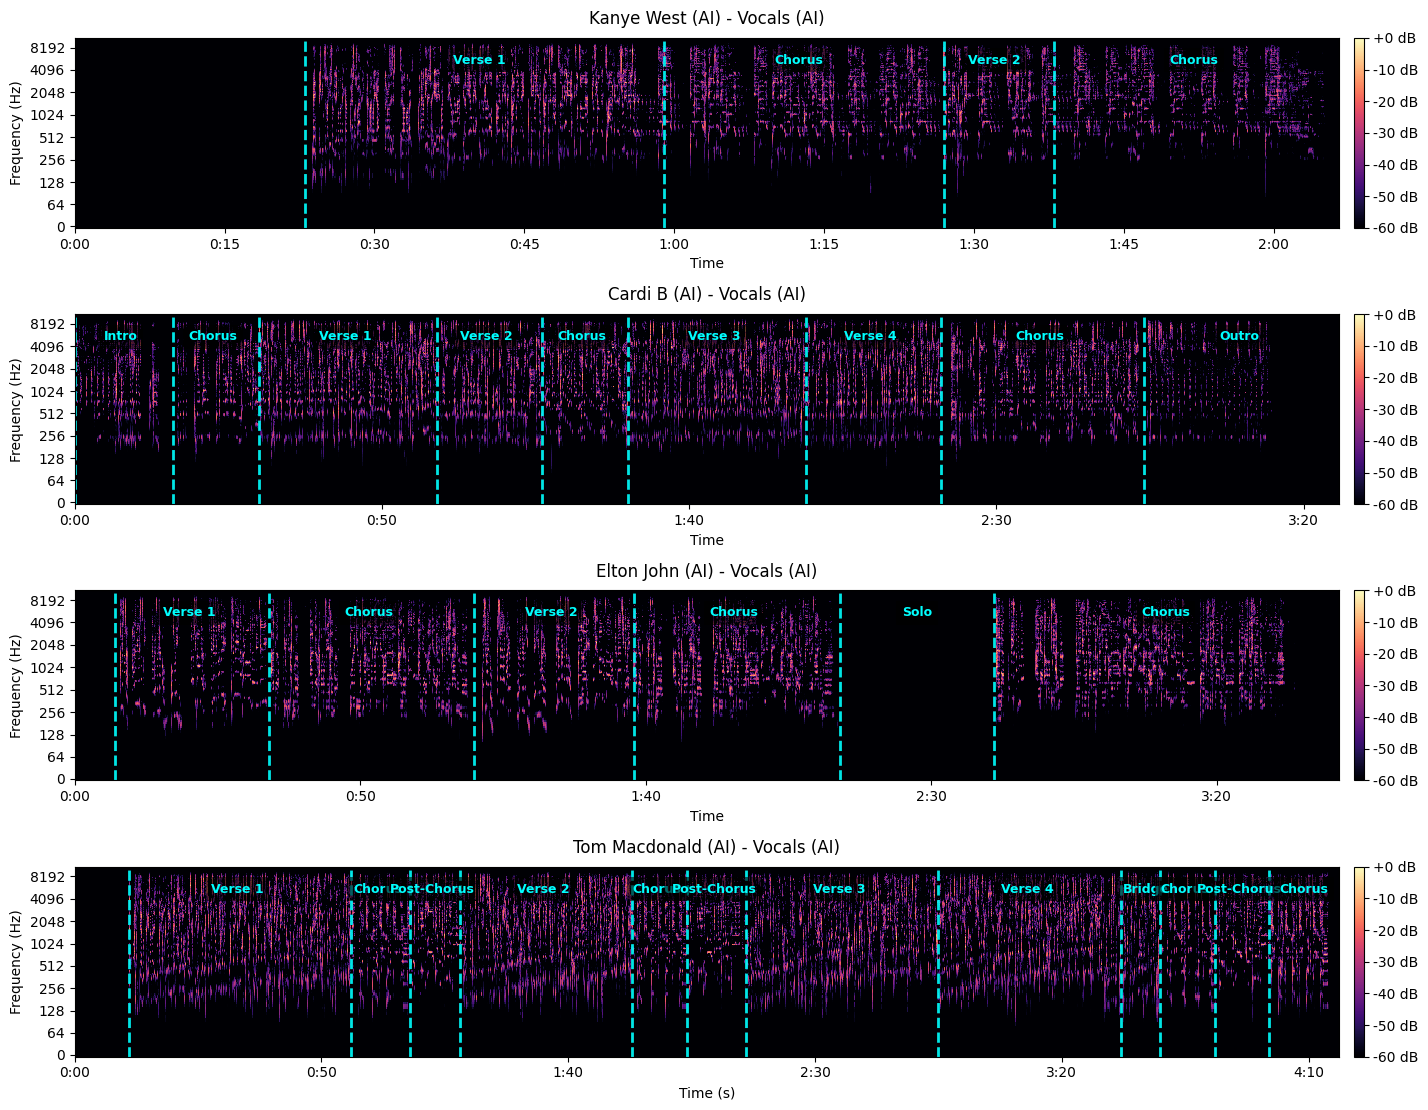

In [5]:
def plot_waveforms(song_dict, title_suffix="Vocals"):
    plt.figure(figsize=(16, 2.8 * len(song_dict)))

    for i, (artist, data) in enumerate(song_dict.items(), 1):
        y = data['y']
        sr = data['sr']

        plt.subplot(len(song_dict), 1, i)
        # stronger waveform color: deeper blue
        librosa.display.waveshow(y, sr=sr, color='#0055FF', alpha=0.85)
        plt.title(f"{artist} - {title_suffix}", pad=10, fontsize=12)
        plt.ylabel("Amplitude")

        # add section markers
        if artist in song_sections:
            for start, end, label in song_sections[artist]:
                plt.axvline(x=start, color='crimson', linestyle='--', linewidth=2, alpha=0.8)
                plt.text(
                    x=start + (end - start) / 2,
                    y=0.8 * np.max(y),
                    s=label,
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
                )

        if i < len(song_dict):
            plt.xticks([])
        else:
            plt.xlabel("Time (s)")

    plt.tight_layout()
    plt.show()


# spectrograms (from full songs or vocals)
def plot_spectrograms(song_dict, title_suffix="Full Song"):
    plt.figure(figsize=(16, 2.8 * len(song_dict)))

    for i, (artist, data) in enumerate(song_dict.items(), 1):
        y = data['y']
        sr = data['sr']

        plt.subplot(len(song_dict), 1, i)
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        librosa.display.specshow(
            D, sr=sr, x_axis='time', y_axis='log',
            cmap='magma', vmin=-60, vmax=0
        )
        plt.colorbar(format='%+2.0f dB', pad=0.01)
        plt.title(f"{artist} - {title_suffix}", pad=10, fontsize=12)
        plt.ylabel("Frequency (Hz)")

        # add section markers
        if artist in song_sections:
            for start, end, label in song_sections[artist]:
                plt.axvline(x=start, color='cyan', linestyle='--', linewidth=2, alpha=0.9)
                plt.text(
                    x=start + (end - start) / 2,
                    y=sr / 4,  # place label around mid frequency
                    s=label,
                    color='cyan',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.6, edgecolor='none')
                )

        if i == len(song_dict):
            plt.xlabel("Time (s)")

    plt.tight_layout()
    plt.show()


# --- split originals vs AI ---
original_vocals = {k: v for k, v in vocals.items() if "(AI)" not in k}
ai_vocals       = {k: v for k, v in vocals.items() if "(AI)" in k}


plot_waveforms(original_vocals, "Vocals (Original)")
plot_waveforms(ai_vocals, "Vocals (AI)")
plot_spectrograms(original_vocals, "Vocals (Original)")
plot_spectrograms(ai_vocals, "Vocals (AI)")

In [6]:
def cpp(y, sr, frame_length=2048, hop_length=512):
    """Cepstral Peak Prominence (CPP) in dB - robust version."""
    frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length).T
    window = np.hanning(frame_length)
    cpp_vals = []
    
    for frame in frames:
        frame = frame * window
        S = np.abs(np.fft.rfft(frame)) + 1e-12
        logS = np.log(S)
        ceps = np.fft.irfft(logS)
        
        # Proper quefrency range for vocals (2–20 ms)
        min_quef = int(0.002 * sr)  # 2 ms = 500 Hz
        max_quef = int(0.020 * sr)  # 20 ms = 50 Hz
        min_quef = max(min_quef, 1)
        max_quef = min(max_quef, len(ceps) - 1)
        
        if max_quef > min_quef:
            cepstral_region = ceps[min_quef:max_quef]
            if len(cepstral_region) > 0:
                peak = np.max(cepstral_region)
                baseline = np.median(ceps)
                if peak > baseline > 0:
                    cpp_db = 10 * np.log10(peak / baseline)
                    cpp_vals.append(cpp_db)
    
    return np.nanmean(cpp_vals) if cpp_vals else 0


def extract_parselmouth_features(y, sr):
    """Extract mean F0, HNR, jitter, shimmer using Parselmouth."""
    sound = parselmouth.Sound(y, sampling_frequency=sr)
    
    # Pitch (F0)
    pitch = sound.to_pitch(time_step=0.01, pitch_floor=50, pitch_ceiling=350)
    f0_values = pitch.selected_array['frequency']
    f0_values[f0_values == 0] = np.nan
    mean_f0 = np.nanmean(f0_values)
    
    # HNR (already in dB)
    try:
        hnr_obj = parselmouth.praat.call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        mean_hnr = parselmouth.praat.call(hnr_obj, "Get mean", 0, 0)
    except:
        mean_hnr = np.nan
    
    # Jitter and Shimmer
    try:
        pp = parselmouth.praat.call(sound, "To PointProcess (periodic, cc)", 75, 350)
        jitter = parselmouth.praat.call(pp, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer = parselmouth.praat.call([sound, pp], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    except:
        jitter = np.nan
        shimmer = np.nan
    
    return mean_f0, mean_hnr, jitter, shimmer


def extract_energy_and_centroid(y, sr):
    """Compute mean energy (RMS) and spectral centroid."""
    # Energy (RMS)
    rms = librosa.feature.rms(y=y)[0]
    mean_energy = np.mean(rms)
    
    # Spectral Centroid (brightness)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    mean_centroid = np.mean(centroid)
    
    return mean_energy, mean_centroid


def extract_core_vocal_features(vocals):
    """
    Extract core vocal features: mean F0, HNR, CPP, jitter, shimmer, energy, spectral centroid.
    """
    results = {}
    for name, data in vocals.items():
        y = data["y"]
        sr = data["sr"]
        
        # Parselmouth features
        mean_f0, mean_hnr, jitter, shimmer = extract_parselmouth_features(y, sr)
        
        # CPP
        mean_cpp = cpp(y, sr)
        
        # Energy & Spectral Centroid
        mean_energy, mean_centroid = extract_energy_and_centroid(y, sr)
        
        results[name] = {
            "mean_f0": mean_f0,
            "mean_hnr": mean_hnr,          # dB
            "mean_cpp": mean_cpp,          # dB
            "mean_jitter": jitter,         # proportion
            "mean_shimmer": shimmer,       # proportion
            "mean_energy": mean_energy,    # RMS energy
            "mean_spectral_centroid": mean_centroid,  # Hz
            "is_ai": "(AI)" in name,
            "base_artist": name.split(' (AI)')[0] if '(AI)' in name else name
        }
    
    return pd.DataFrame(results).T

In [7]:
df_results = extract_core_vocal_features(vocals)
df_results

,mean_f0,mean_hnr,mean_cpp,mean_jitter,mean_shimmer,mean_energy,mean_spectral_centroid,is_ai,base_artist
Kanye West,269.386511,3.052054,12.189188,0.016164,0.129361,0.023363,2117.489745,False,Kanye West
Cardi B,252.505158,5.756538,27.012681,0.01921,0.149914,0.025011,3547.95823,False,Cardi B
Elton John,235.123062,5.347029,12.929431,0.029737,0.165393,0.0111,2314.498047,False,Elton John
Tom Macdonald,221.449704,6.481339,22.716986,0.020262,0.139699,0.028717,3524.885805,False,Tom Macdonald
Kanye West (AI),258.874371,8.421819,17.944493,0.018111,0.122525,0.021254,2873.805749,True,Kanye West
Cardi B (AI),258.293344,7.593895,22.198681,0.019498,0.130899,0.022747,3239.953946,True,Cardi B
Elton John (AI),224.478536,8.51249,16.393516,0.034091,0.144793,0.026977,2447.570365,True,Elton John
Tom Macdonald (AI),247.741749,7.674678,23.983298,0.024371,0.125369,0.038674,3292.583816,True,Tom Macdonald


HNR: higher HNR means cleaner, harmonic voice higher = less aggresive

Pitch variability (f0_std), unstable pitch, lower = less aggerssive

mean flatness, noisy chaotic, lower = less aggressive

mean_cpp, clear vibration, higher = less aggressive

mean_voiced_prob, stable voicing, higher = less aggressive.


In [8]:
df_results.to_csv("pitch_features.csv")

In [9]:
df = df_results

In [10]:
df

,mean_f0,mean_hnr,mean_cpp,mean_jitter,mean_shimmer,mean_energy,mean_spectral_centroid,is_ai,base_artist
Kanye West,269.386511,3.052054,12.189188,0.016164,0.129361,0.023363,2117.489745,False,Kanye West
Cardi B,252.505158,5.756538,27.012681,0.01921,0.149914,0.025011,3547.95823,False,Cardi B
Elton John,235.123062,5.347029,12.929431,0.029737,0.165393,0.0111,2314.498047,False,Elton John
Tom Macdonald,221.449704,6.481339,22.716986,0.020262,0.139699,0.028717,3524.885805,False,Tom Macdonald
Kanye West (AI),258.874371,8.421819,17.944493,0.018111,0.122525,0.021254,2873.805749,True,Kanye West
Cardi B (AI),258.293344,7.593895,22.198681,0.019498,0.130899,0.022747,3239.953946,True,Cardi B
Elton John (AI),224.478536,8.51249,16.393516,0.034091,0.144793,0.026977,2447.570365,True,Elton John
Tom Macdonald (AI),247.741749,7.674678,23.983298,0.024371,0.125369,0.038674,3292.583816,True,Tom Macdonald


In [11]:
sns.set(style="whitegrid", palette="muted", font_scale=1.2)


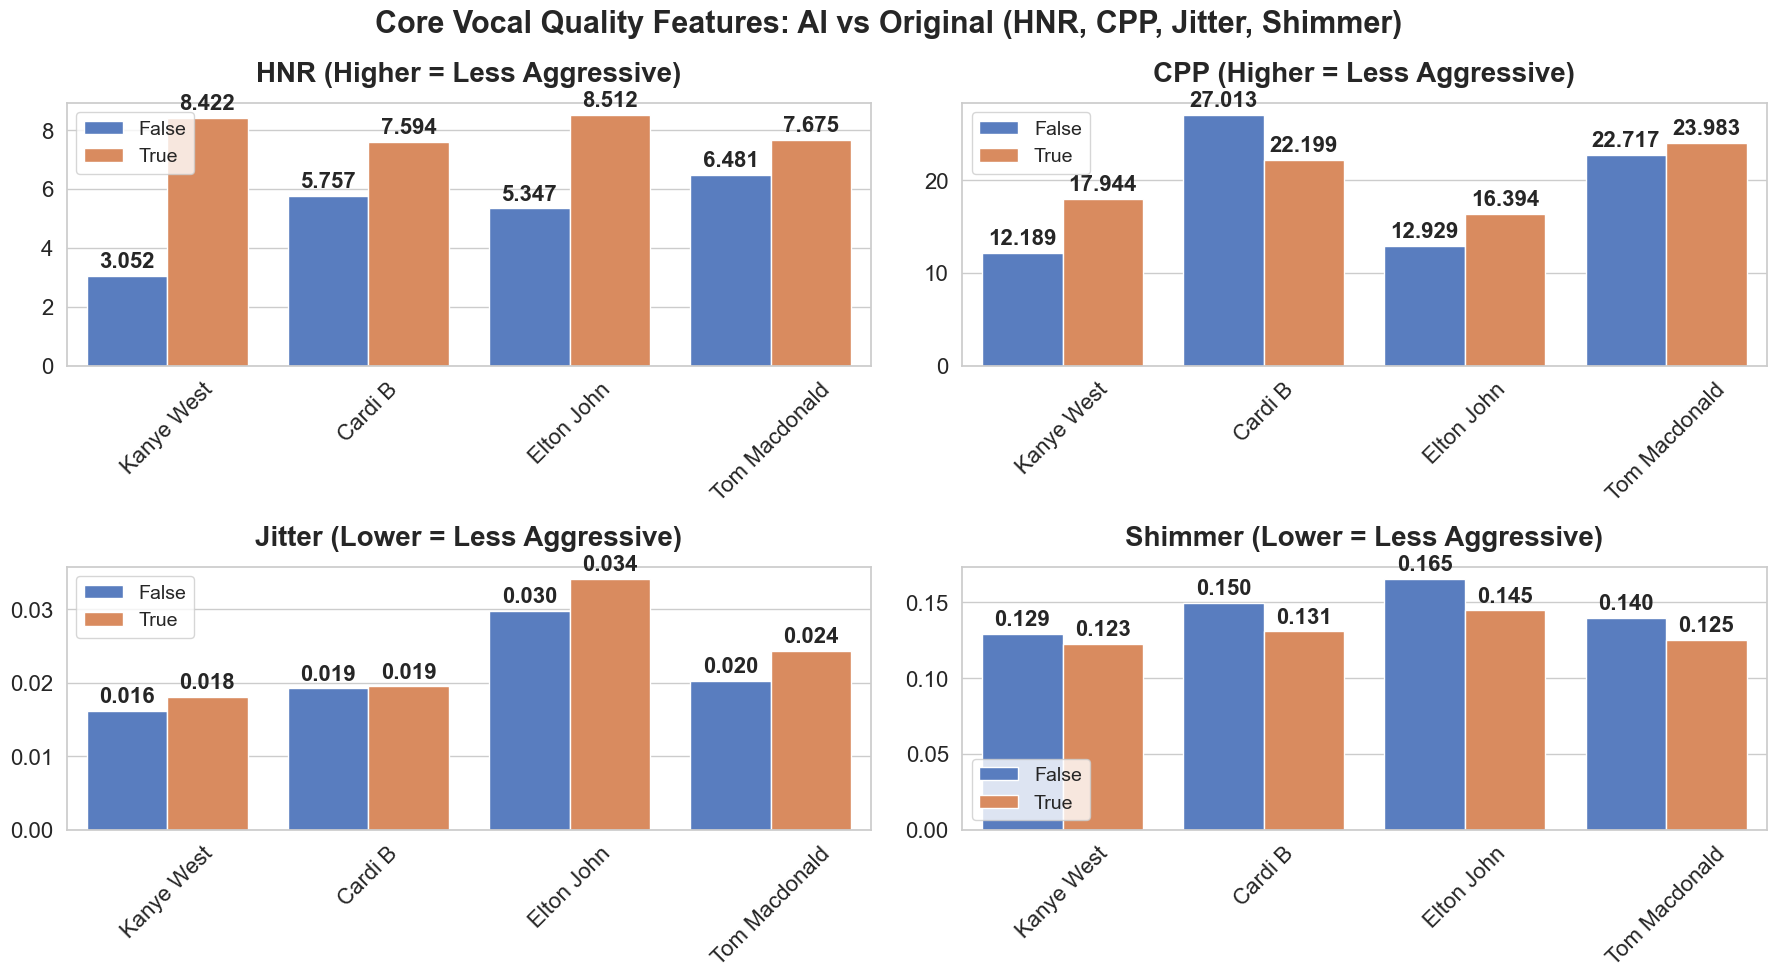

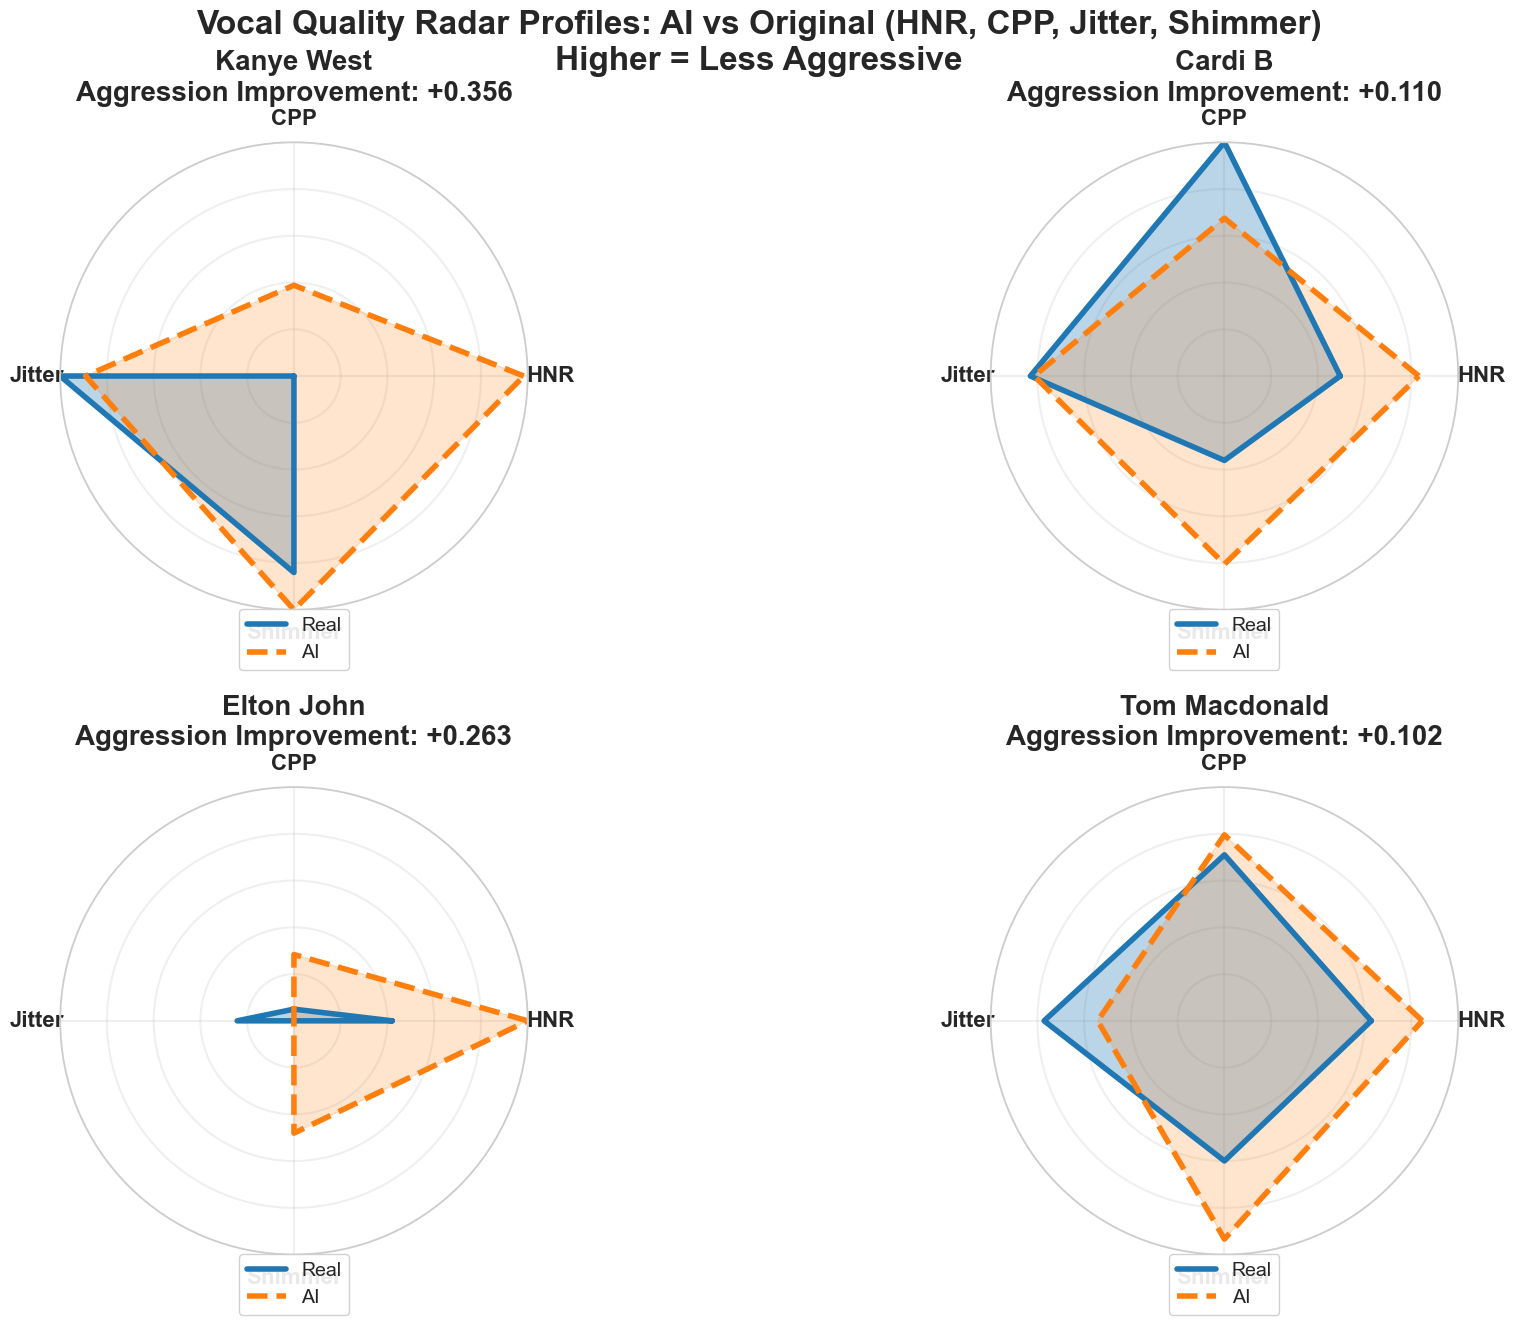

In [12]:
artists = df['base_artist'].unique()

# --- Focused Barplots: 4 Features ---
core_features = ['mean_hnr', 'mean_cpp', 'mean_jitter', 'mean_shimmer']
core_names = [
    'HNR (Higher = Less Aggressive)', 
    'CPP (Higher = Less Aggressive)', 
    'Jitter (Lower = Less Aggressive)',
    'Shimmer (Lower = Less Aggressive)'
]

n_features = len(core_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, (feature, name) in enumerate(zip(core_features, core_names)):
    ax = axes[idx]
    sns.barplot(data=df, x='base_artist', y=feature, hue='is_ai', ax=ax)
    ax.set_title(name, fontsize=20, fontweight='bold', pad=15)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=16)
    ax.tick_params(axis='y', labelsize=16)
    ax.legend(fontsize=14)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=16, fontweight='bold')

# Hide unused axes
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Core Vocal Quality Features: AI vs Original (HNR, CPP, Jitter, Shimmer)', 
             fontsize=22, y=0.98, fontweight='bold')
plt.tight_layout()
plt.show()


# --- RADAR CHARTS (4 Features) ---
fig, axes = plt.subplots(2, 2, figsize=(20, 14), subplot_kw=dict(polar=True))
axes = axes.flatten()

categories = ['HNR', 'CPP', 'Jitter', 'Shimmer']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

df_radar = df.copy()

# --- Normalize all features ---
# Higher = less aggressive
for feature in ['mean_hnr', 'mean_cpp']:
    df_radar[f'{feature}_norm'] = (df_radar[feature] - df_radar[feature].min()) / (df_radar[feature].max() - df_radar[feature].min())

# Lower = less aggressive → invert
for feature in ['mean_jitter', 'mean_shimmer']:
    df_radar[f'{feature}_norm'] = 1 - (df_radar[feature] - df_radar[feature].min()) / (df_radar[feature].max() - df_radar[feature].min())

for idx, artist in enumerate(artists):
    ax = axes[idx]
    
    real_row = df_radar[(df_radar['base_artist'] == artist) & (~df_radar['is_ai'])].iloc[0]
    ai_row = df_radar[(df_radar['base_artist'] == artist) & (df_radar['is_ai'])].iloc[0]
    
    features = ['mean_hnr', 'mean_cpp', 'mean_jitter', 'mean_shimmer']
    
    values_real = [real_row[f'{f}_norm'] for f in features] + [real_row[f'{features[0]}_norm']]
    values_ai = [ai_row[f'{f}_norm'] for f in features] + [ai_row[f'{features[0]}_norm']]
    
    # Plot real
    ax.plot(angles, values_real, linewidth=4, label='Real', color='#1f77b4')
    ax.fill(angles, values_real, alpha=0.3, color='#1f77b4')
    
    # Plot AI
    ax.plot(angles, values_ai, linewidth=4, label='AI', color='#ff7f0e', linestyle='--')
    ax.fill(angles, values_ai, alpha=0.2, color='#ff7f0e')
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=16, fontweight='bold')
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, linewidth=1.5)
    
    # Mean difference
    aggression_improvement = np.mean([values_ai[i] - values_real[i] for i in range(len(values_real)-1)])
    
    ax.set_title(f'{artist}\nAggression Improvement: {aggression_improvement:+.3f}', 
                 size=20, pad=30, fontweight='bold')
    ax.legend(loc='lower center', fontsize=14, framealpha=0.9, bbox_to_anchor=(0.5, -0.15))

plt.suptitle('Vocal Quality Radar Profiles: AI vs Original (HNR, CPP, Jitter, Shimmer)\nHigher = Less Aggressive', 
             size=24, y=0.95, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
df_radar

,mean_f0,mean_hnr,mean_cpp,mean_jitter,mean_shimmer,mean_energy,mean_spectral_centroid,is_ai,base_artist,mean_hnr_norm,mean_cpp_norm,mean_jitter_norm,mean_shimmer_norm
Kanye West,269.386511,3.052054,12.189188,0.016164,0.129361,0.023363,2117.489745,False,Kanye West,0.0,0.0,1.0,0.840552
Cardi B,252.505158,5.756538,27.012681,0.01921,0.149914,0.025011,3547.95823,False,Cardi B,0.495287,1.0,0.830097,0.361097
Elton John,235.123062,5.347029,12.929431,0.029737,0.165393,0.0111,2314.498047,False,Elton John,0.420292,0.049937,0.242874,0.0
Tom Macdonald,221.449704,6.481339,22.716986,0.020262,0.139699,0.028717,3524.885805,False,Tom Macdonald,0.628024,0.71021,0.771433,0.599379
Kanye West (AI),258.874371,8.421819,17.944493,0.018111,0.122525,0.021254,2873.805749,True,Kanye West,0.983395,0.388256,0.891394,1.0
Cardi B (AI),258.293344,7.593895,22.198681,0.019498,0.130899,0.022747,3239.953946,True,Cardi B,0.831773,0.675245,0.814024,0.804667
Elton John (AI),224.478536,8.51249,16.393516,0.034091,0.144793,0.026977,2447.570365,True,Elton John,1.0,0.283626,0.0,0.48054
Tom Macdonald (AI),247.741749,7.674678,23.983298,0.024371,0.125369,0.038674,3292.583816,True,Tom Macdonald,0.846567,0.795636,0.542194,0.933669


In [14]:
# semantic analysis


In [17]:
from sentence_transformers import SentenceTransformer


In [18]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')


c:\Users\jiyon\Desktop\Programming_projects\UNSW\musictransformationanalysis\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jiyon\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 